In [1]:
import cv2
from deepface import DeepFace
import dlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
import torch
from ultralytics import YOLO

In [119]:
import io
import base64
from IPython.display import HTML

VIDEO_PATH = "./sample/People using Mobile Phones.mp4"

video = io.open(VIDEO_PATH, "r+b").read()
encoded = base64.b64encode(video)
HTML(data=f'''<video controls><source src="data:video/mp4;base64,{encoded.decode("ascii")}" type="video/mp4"/></video>''')

## Detect & Track Faces with YOLO

In [120]:
detect_model = YOLO("../outputs/models/yolo-detect.pt")
result = detect_model.track(VIDEO_PATH, conf=0.6, iou=0.5)


WARNING 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/242) d:\Local Workspace\AOL Deep Learning\notebooks\sample\People using Mobile Phones.mp4: 192x320 3 faces, 45.2ms
video 1/1 (frame 2/242) d:\Local Workspace\AOL Deep Learning\notebooks\sample\People using Mobile Phones.mp4: 192x320 3 faces, 44.2ms
video 1/1 (frame 3/242) d:\Local Workspace\AOL Deep Learning\notebooks\sample\People using Mobile Phones.mp4: 192x320 3 faces, 34.8ms
video 1/1 (frame 4/242) d:\Local Workspace\AOL Deep Learn

# Computing Face Quality

Each face image will be scored based on three components:

1. YOLO confidence score (higher = better)
2. Bounding box size (larger = better)
3. Distance to frame center (closer to center = better)

In [ ]:
def face_score(face_conf: float, orig_shape: tuple[int], box: tuple[int], conf_weight: float = 0.65, box_weight: float = 0.1, center_weight: float = 0.25) -> float:	
	# Face Confidence
	score_conf = conf_weight * face_conf

	# Box Size
	x1, y1, x2, y2 = box
	box_area = (y2 - y1) * (x2 - x1)
	frame_area = orig_shape[0] * orig_shape[1]
	score_boxsize =  box_weight * (box_area / frame_area)

	# Distance to Center
	center_box = (y1 + (y2 - y1) / 2, x1 + (x2 - x1) / 2)
	center_frame = np.array(orig_shape) / 2
	edge_dist = np.array((min(center_box[0], orig_shape[0] - center_box[0]), min(center_box[1], orig_shape[1] - center_box[1])))
	score_center = center_weight * np.min((edge_dist / center_frame) ** 2)

	score = (score_conf + score_boxsize + score_center) / (conf_weight + box_weight + center_weight)
	return float(score)

In [122]:
# 	track_id:
# 		frame_no
# 		score
# 		xyxy
tracked_faces: dict[int, list[tuple[int, float, list[int]]]] = dict()

def append_tracked_face(track_id: int, frame_no: int, score: float, xyxy: list[int]):
	if track_id not in tracked_faces: tracked_faces[track_id] = []
	tracked_faces[track_id].append((frame_no, score, xyxy))

# Collected all boxes of faces based on their tracking id
for fno, frame in enumerate(result):
	if frame.boxes.id is None: continue
	ids = frame.boxes.id.int()
	confs = frame.boxes.conf
	coords = torch.round(frame.boxes.xyxy).int()
	frame.orig_shape

	for id, conf, xyxy in zip(ids, confs, coords):
		append_tracked_face(id.item(), fno, face_score(conf.item(), frame.orig_shape, xyxy.tolist()), xyxy.tolist())

## Select Best Face

From a set of tracked faces, sort the faces by their score and select the best ones to generate embeddings.

In [123]:
for track_id in tracked_faces.keys():
	tracked_faces[track_id].sort(key=lambda x: x[1], reverse=True)

## 5-point Face Alignment with dlib

Improves embedding by straightening the faces.

In [124]:
shape_predictor = dlib.shape_predictor("../outputs/models/shape_predictor_5_face_landmarks.dat")

def align_face(orig_img: np.array, box: list[int]):
	x1, y1, x2, y2 = box
	shape = shape_predictor(orig_img, dlib.rectangle(x1, y1, x2, y2))
	aligned = dlib.get_face_chip(orig_img, shape, size=160)	
	return aligned

## Embedding Generation with Facenet512

Generate vector embeddings for the top K face images of each tracked face and calculate the average embedding values.

In [125]:
embeddings_list = []
TOP_K_FACES = 3

for i, faces_by_trkid in tracked_faces.items():
	cur_embedding = []
	for j in range(min(len(faces_by_trkid), TOP_K_FACES)):
		(fno, _, box) = faces_by_trkid[j]
		face = align_face(result[fno].orig_img, box)
		embedding = DeepFace.represent(face, model_name="Facenet512", enforce_detection=False, detector_backend="skip", align=False)
		cur_embedding.append(embedding[0]["embedding"])
	
	mean_embedding = np.mean(np.array(cur_embedding), axis=0)
	embeddings_list.append(mean_embedding)
	print(f"Face {i} generated.")

Face 1 generated.
Face 2 generated.
Face 3 generated.
Face 4 generated.
Face 5 generated.
Face 6 generated.
Face 7 generated.
Face 8 generated.


## Clustering with DBSCAN

Group together similar faces by comparing its vector embeddings through cosine similarity.

In [126]:
embeddings_list = np.array(embeddings_list)
embeddings_list.shape

(8, 512)

In [127]:
clustering = DBSCAN(eps=0.25, min_samples=1, metric="cosine").fit(embeddings_list)
clustering.labels_

array([0, 1, 2, 3, 4, 5, 6, 7])

In [128]:
clustered_faces = []

for face, cluster_id in zip(tracked_faces.values(), clustering.labels_):
	if cluster_id == -1: continue
	if cluster_id == len(clustered_faces): clustered_faces.append([])
	clustered_faces[cluster_id].append(face[0])

In [129]:
len(clustered_faces)

8

## Show Detected Faces

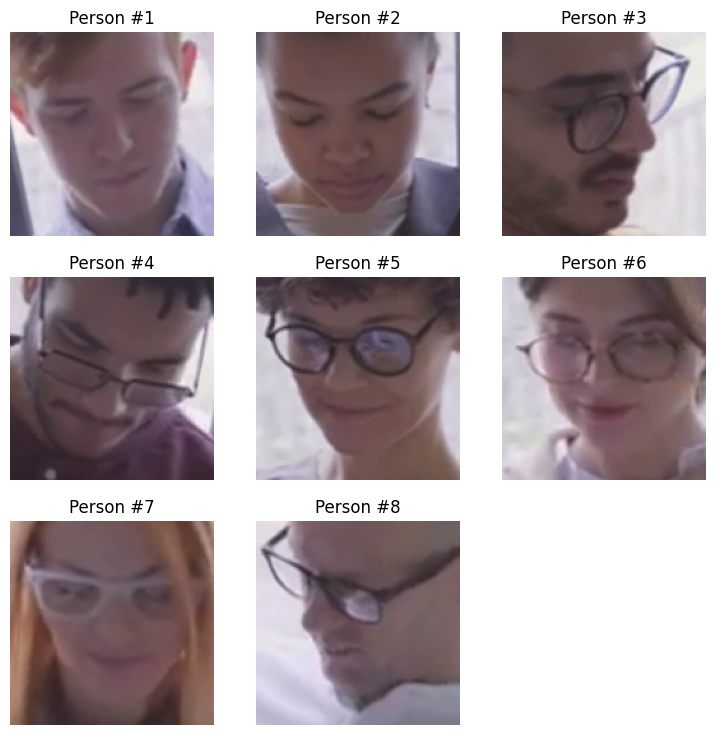

In [130]:
from math import ceil, sqrt

ncells = ceil(sqrt(len(clustered_faces)))

plt.figure(figsize=(3 * ncells, 3 * ncells))

for i, cls_face in enumerate(clustered_faces, start=1):
	plt.subplot(ncells, ncells, i)
	
	fno, _, box = max(cls_face, key=lambda x: x[1])
	face = align_face(result[fno].orig_img, box)
	face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

	plt.title(f"Person #{i}")
	plt.imshow(face)
	plt.axis("off")

plt.show()